# Handling Outliers

### Percentile

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
from matplotlib import pyplot as plt
from sklearn.impute import SimpleImputer as si

In [2]:
df_out = pd.read_csv('weight-height.csv')

In [3]:
df_out.head()

,Gender,Height,Weight
0,Male,73.847017,241.893563
1,Male,68.781904,162.310473
2,Male,74.110105,212.740856
3,Male,71.730978,220.042470
4,Male,69.881796,206.349801


C:\Users\MISHAL MITTAL\AppData\Local\Temp\ipykernel_28488\3059088038.py:2: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df_out['Height'])
C:\Users\MISHAL MITTAL\AppData\Local\Temp\ipykernel_28488\3059088038.py:5: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df_out['Weight'])


<Axes: ylabel='Height'>

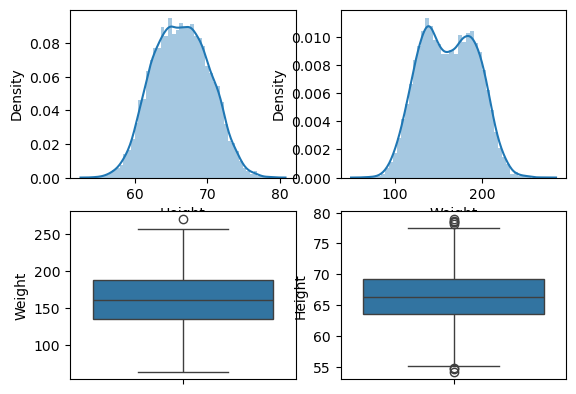

In [6]:
plt.subplot(2,2,1)
sns.distplot(df_out['Height'])

plt.subplot(2,2,2)
sns.distplot(df_out['Weight'])

plt.subplot(2,2,3)
sns.boxplot(df_out['Weight'])

plt.subplot(2,2,4)
sns.boxplot(df_out['Height'])

In [7]:
min_limit = df_out['Height'].quantile(0.01)
max_limit = df_out['Height'].quantile(0.99)

print( max_limit , ',', min_limit)

74.7857900583366 , 58.13441158671655


### Trimming

In [8]:
df_out1 = df_out.copy()

In [9]:
df_out1.shape

(10000, 3)

In [10]:
df_out1[(df_out1['Height'] > max_limit) | (df_out1['Height'] < min_limit)]

,Gender,Height,Weight
23,Male,75.205974,228.761781
190,Male,76.709835,235.035419
197,Male,75.944460,231.924749
202,Male,75.140821,224.124271
215,Male,74.795375,232.635403
...,...,...,...
9761,Female,56.975279,90.341784
9825,Female,55.979198,85.417534
9895,Female,57.740192,93.652957
9904,Female,57.028857,101.202551


In [11]:
df_out1 = df_out1[(df_out1['Height'] <= max_limit) & (df_out1['Height'] >= min_limit)]

In [12]:
df_out1.shape

(9800, 3)

<Axes: ylabel='Height'>

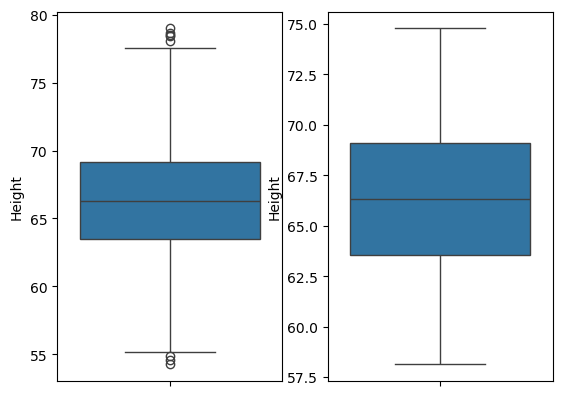

In [13]:
plt.subplot(1,2,1)
sns.boxplot(df_out['Height'])

plt.subplot(1,2,2)
sns.boxplot(df_out1['Height'])

### Capping

In [14]:
df_out2 = df_out.copy()

In [15]:
df_out2.shape

(10000, 3)

In [16]:
df_out2['Height'] = np.where((df_out2['Height'] > max_limit), max_limit ,
                                             (np.where((df_out2['Height'] < min_limit), min_limit, df_out2['Height'])))

In [17]:
df_out2.shape

(10000, 3)

<Axes: ylabel='Height'>

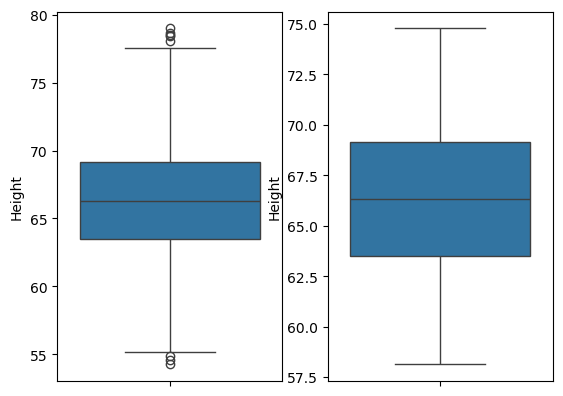

In [18]:
plt.subplot(1,2,1)
sns.boxplot(df_out['Height'])

plt.subplot(1,2,2)
sns.boxplot(df_out2['Height'])